In [2]:
import pandas as pd
import numpy as np

In [3]:

# 加载威斯康星乳腺癌数据集
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

# 转换为DataFrame格式，便于查看
cancer_df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
cancer_df['TARGET'] = cancer.target  # 添加肿瘤类型列

# 打印核心数据
print('数据集形状（样本数×特征数）：', cancer_df.shape)
print('缺失值检查：', cancer_df.isnull().sum())  # 无缺失值
print('肿瘤类型分布：', cancer_df['TARGET'].value_counts().rename({0:'恶性', 1:'良性'}))

# 提取特征和目标变量
X_c = cancer_df.drop('TARGET', axis=1)
y_c = cancer_df['TARGET']


数据集形状（样本数×特征数）： (569, 31)
缺失值检查： mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
TARGET                     0
dtype: int64
肿瘤类型分布： TARGET
良性    357
恶性    212
Name: count, dtype: 

In [5]:
# 数据集划分：将数据分成训练集（训练模型）和测试集（验证模型）
from sklearn.model_selection import train_test_split

# 数据预处理：特征标准化（统一量纲）
from sklearn.preprocessing import StandardScaler

# 回归算法模型：线性回归、随机森林回归、XGBoost回归
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# 分类算法模型：逻辑回归（二分类）
from sklearn.linear_model import LogisticRegression

# 模型评估指标：回归和分类专用指标
from sklearn.metrics import mean_squared_error, r2_score  # 回归指标（MSE、R²）
from sklearn.metrics import accuracy_score, confusion_matrix  # 分类指标

# 数据可视化：绘制图表，直观查看结果
import matplotlib.pyplot as plt
import seaborn as sns

# 忽略无关警告（避免代码运行时出现多余警告，不影响结果）
import warnings
warnings.filterwarnings('ignore')

# 设置可视化样式：显示中文、取消负号乱码（必加，否则图表中文乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [6]:
# 标准化特征（统一量纲，提升模型训练效果）
scaler_c = StandardScaler()
X_c_scaled = scaler_c.fit_transform(X_c)
# 训练集70%，测试集30%，固定随机种子，保证可复现
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c_scaled, y_c, test_size=0.3, random_state=42
)

print('训练集样本数：', X_c_train.shape[0])
print('测试集样本数：', X_c_test.shape[0])


训练集样本数： 398
测试集样本数： 171


逻辑回归分类模型训练完成！
逻辑回归模型准确率：0.9825（越接近1越好）


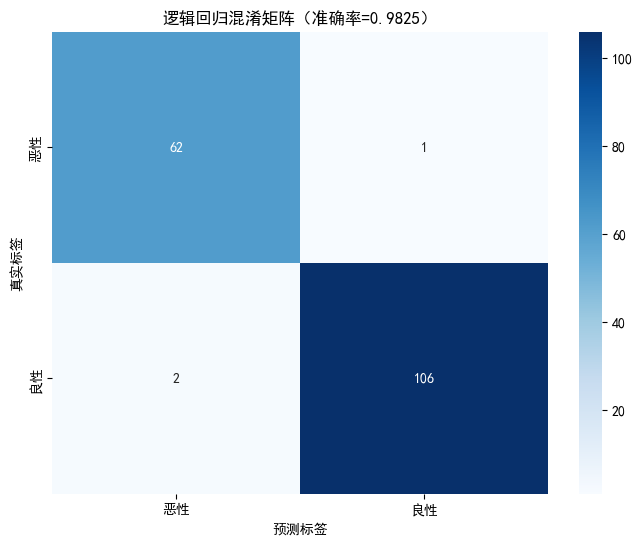


混淆矩阵解读：
左上角数字：真实为恶性、预测为恶性的样本数（预测正确）
右上角数字：真实为恶性、预测为良性的样本数（预测错误）
左下角数字：真实为良性、预测为恶性的样本数（预测错误）
右下角数字：真实为良性、预测为良性的样本数（预测正确）


In [8]:
# 初始化逻辑回归模型（max_iter=1000，保证模型能收敛）
lr_classifier = LogisticRegression(random_state=42, max_iter=1000)

# 用训练集训练模型
lr_classifier.fit(X_c_train, y_c_train)
print('逻辑回归分类模型训练完成！')

# 用测试集预测
y_c_pred = lr_classifier.predict(X_c_test)

# 计算核心评估指标（准确率）
acc = accuracy_score(y_c_test, y_c_pred)
print(f'逻辑回归模型准确率：{acc:.4f}（越接近1越好）')

# 绘制混淆矩阵（直观查看预测对错的数量）
cm = confusion_matrix(y_c_test, y_c_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['恶性', '良性'],
            yticklabels=['恶性', '良性'])
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.title(f'逻辑回归混淆矩阵（准确率={acc:.4f}）')
plt.show()

# 混淆矩阵解读
print('\n混淆矩阵解读：')
print('左上角数字：真实为恶性、预测为恶性的样本数（预测正确）')
print('右上角数字：真实为恶性、预测为良性的样本数（预测错误）')
print('左下角数字：真实为良性、预测为恶性的样本数（预测错误）')
print('右下角数字：真实为良性、预测为良性的样本数（预测正确）')
